In [1]:
#pip install lime shap --quiet

In [2]:
#pip install scikeras --quiet

In [3]:
#pip install keras-tuner

## Importing libraries 

In [4]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import itertools
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import random
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

Using balanced dataset after EDA and Data Cleaning

Image count per class: {'drink': 15670, 'food': 20000, 'inside': 20000, 'menu': 20000, 'outside': 18569}


C:\Users\Taranjot\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


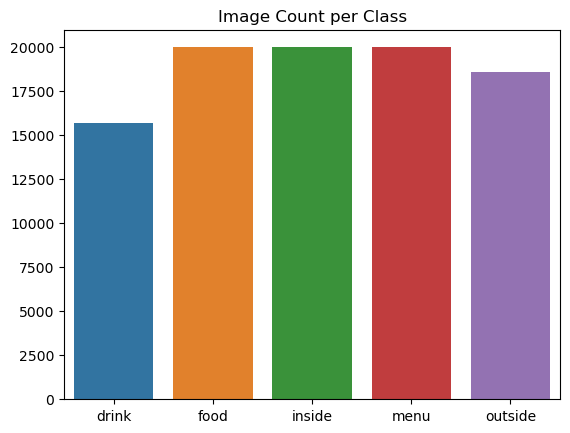

In [5]:
base_dir = r"D:\Downloads\balanced_labeled_photos\balanced_labeled_photos"  # Replace this
classes = ['drink', 'food', 'inside', 'menu', 'outside']

# Count images per class
image_counts = {label: len(os.listdir(os.path.join(base_dir, label))) for label in classes}
print("Image count per class:", image_counts)

# Plotting class distribution
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()))
plt.title("Image Count per Class")
plt.show()

Making sure each class has equal count so that we get a proper model 

In [5]:
import os
import shutil
import random

# Set your original dataset and destination directory
original_dir = r"D:\Downloads\balanced_labeled_photos\balanced_labeled_photos"  
output_dir = r"D:\Downloads\model_dataset"   

# Ensure destination folder exists
os.makedirs(output_dir, exist_ok=True)

# Target images per class
target_count = 10000

# Loop through each class folder
for class_name in os.listdir(original_dir):
    class_path = os.path.join(original_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        selected = random.sample(images, target_count)  # Randomly select 10,000

        output_class_dir = os.path.join(output_dir, class_name)
        os.makedirs(output_class_dir, exist_ok=True)

        for img in selected:
            src = os.path.join(class_path, img)
            dst = os.path.join(output_class_dir, img)
            shutil.copy2(src, dst)

        print(f"{class_name}: {len(selected)} images copied to {output_class_dir}")

drink: 10000 images copied to D:\Downloads\model_dataset\drink
food: 10000 images copied to D:\Downloads\model_dataset\food
inside: 10000 images copied to D:\Downloads\model_dataset\inside
menu: 10000 images copied to D:\Downloads\model_dataset\menu
outside: 10000 images copied to D:\Downloads\model_dataset\outside


Image count per class: {'drink': 10000, 'food': 10000, 'inside': 10000, 'menu': 10000, 'outside': 10000}


C:\Users\Taranjot\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


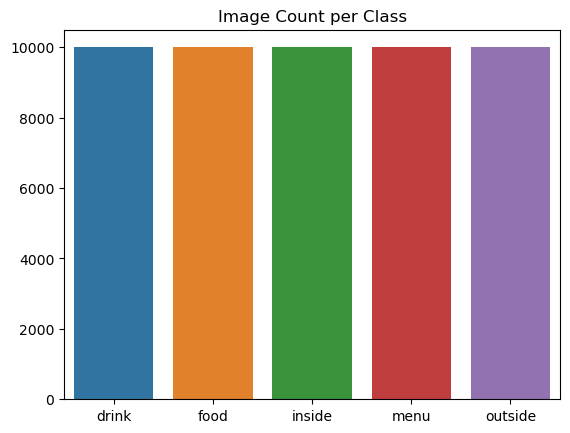

In [6]:
base_dir = r"D:\Downloads\model_dataset"  # Replace this
classes = ['drink', 'food', 'inside', 'menu', 'outside']

# Count images per class
image_counts = {label: len(os.listdir(os.path.join(base_dir, label))) for label in classes}
print("Image count per class:", image_counts)

# Plotting class distribution
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()))
plt.title("Image Count per Class")
plt.show()

## Start Model Building from here using model_dataset

In [7]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import itertools
# dataset
base_dir = r'D:\Downloads\model_dataset'
class_names = sorted(os.listdir(base_dir))  # ['drink', 'food', 'inside', 'menu', 'outside']

In [8]:
print(class_names)

['drink', 'food', 'inside', 'menu', 'outside']


train test Split 

In [15]:
# Image size and batch size
img_height, img_width = 48, 48
batch_size = 32

# Data Augmentation + Validation Split
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    base_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_data = datagen.flow_from_directory(
    base_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 40000 images belonging to 5 classes.
Found 10000 images belonging to 5 classes.


Checking class distribution in training set

In [10]:
import numpy as np
import collections

# Get class labels (dictionary: class name -> index)
class_labels = train_data.class_indices
# Reverse the dictionary to get index -> class name
index_to_class = {v: k for k, v in class_labels.items()}

# Count the occurrences of each class index
class_counts = collections.Counter(train_data.classes)

# Print the number of samples for each class
print("Class distribution in training set:")
for class_index, count in class_counts.items():
    print(f"{index_to_class[class_index]}: {count} images")

Class distribution in training set:
drink: 8000 images
food: 8000 images
inside: 8000 images
menu: 8000 images
outside: 8000 images


Checking class distribution in validation set

In [11]:
import numpy as np
import collections

# Get class labels (dictionary: class name -> index)
val_class_labels = val_data.class_indices
# Reverse the dictionary to get index -> class name
val_index_to_class = {v: k for k, v in val_class_labels.items()}

# Count the occurrences of each class index
val_class_counts = collections.Counter(val_data.classes)

# Print the number of samples for each class
print("Class distribution in validation set:")
for class_index, count in val_class_counts.items():
    print(f"{val_index_to_class[class_index]}: {count} images")

Class distribution in validation set:
drink: 2000 images
food: 2000 images
inside: 2000 images
menu: 2000 images
outside: 2000 images


In [12]:
print("Class Indices:", train_data.class_indices)

Class Indices: {'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}


In [13]:
num_classes = len(class_names)

In [14]:
print(num_classes)

5


## DNN Model 

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    Flatten(input_shape=(img_height, img_width, 3)),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\Taranjot\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 6912)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,539,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,672,069 (14.01 MB)

 Trainable params: 3,672,069 (14.01 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

In [18]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10


C:\Users\Taranjot\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 766s 610ms/step - accuracy: 0.3831 - loss: 1.6568 - val_accuracy: 0.5178 - val_loss: 1.1481 - learning_rate: 0.0010
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 86s 69ms/step - accuracy: 0.4502 - loss: 1.2433 - val_accuracy: 0.5623 - val_loss: 1.0950 - learning_rate: 0.0010
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 88s 70ms/step - accuracy: 0.4944 - loss: 1.1813 - val_accuracy: 0.5666 - val_loss: 1.0372 - learning_rate: 0.0010
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 87s 69ms/step - accuracy: 0.5173 - loss: 1.1436 - val_accuracy: 0.5736 - val_loss: 1.0805 - learning_rate: 0.0010
Epoch 5/10
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5275 - loss: 1.1143
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 86s 69ms/step - accuracy: 0.5275 - loss: 1.1143 - val_accuracy: 0.5698 - val_loss: 1.0556 - learning_rate: 0.0010
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 86s 69ms/step - accuracy: 0.5458 

Train VS Validation Accuracy and Loss 

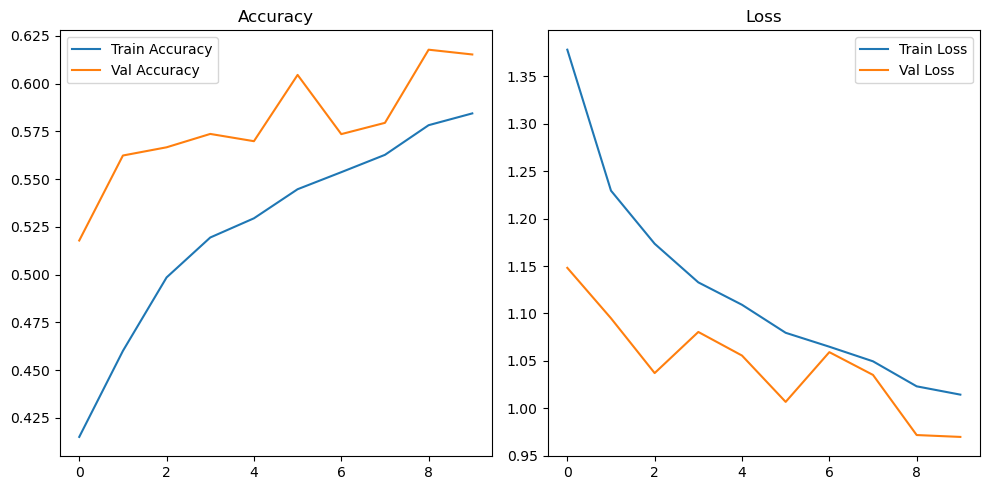

In [19]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step
[[ 685   45  209  621  440]
 [  76  942  930   30   22]
 [  12   27 1863   39   59]
 [ 208   14  188 1299  291]
 [ 125    4  170  338 1363]]


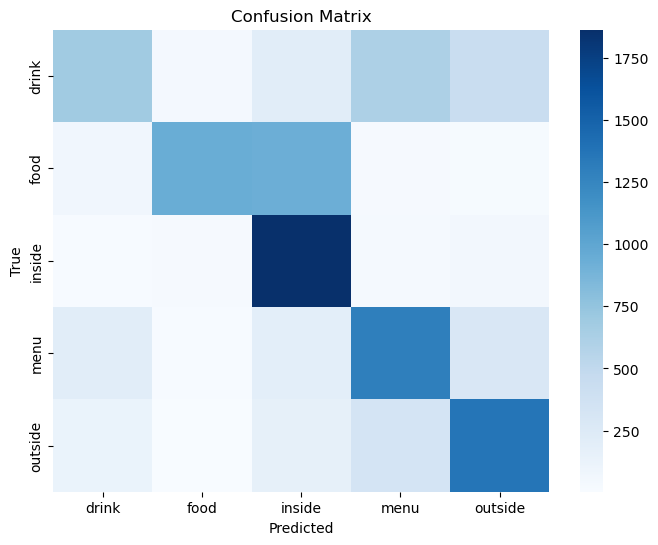

In [22]:
val_data.reset()
y_pred = np.argmax(model.predict(val_data), axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)
print(cm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [23]:
y_true_bin = tf.keras.utils.to_categorical(y_true, num_classes=num_classes)
y_pred_probs = model.predict(val_data)
auc_score = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr')
print(f"Multi-Class AUC Score: {auc_score:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step
Multi-Class AUC Score: 0.8896


## Model Tuning 

In [28]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

def build_model(hp):
    model = Sequential()
    model.add(Flatten(input_shape=(img_height, img_width, 3)))
    
    # First Dense Layer
    model.add(Dense(units=hp.Int('units_1', min_value=128, max_value=1024, step=128),
                    activation=hp.Choice('act_1', ['relu', 'tanh'])))
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1)))
    
    # Second Dense Layer
    model.add(Dense(units=hp.Int('units_2', min_value=64, max_value=512, step=64),
                    activation=hp.Choice('act_2', ['relu', 'tanh'])))
    model.add(Dropout(rate=hp.Float('dropout_2', min_value=0.2, max_value=0.5, step=0.1)))
    
    # Output Layer
    model.add(Dense(num_classes, activation='softmax'))
    
    # Compile model
    model.compile(
        optimizer=hp.Choice('optimizer', ['adam', 'rmsprop']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

Setup Tuner

In [29]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='image_classification_tuning',
    overwrite=True
)

C:\Users\Taranjot\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


 Start the Search

In [30]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
]

tuner.search(train_data,
             validation_data=val_data,
             epochs=10,
             callbacks=callbacks)

Trial 5 Complete [00h 15m 11s]
val_accuracy: 0.6930000185966492

Best val_accuracy So Far: 0.6930000185966492
Total elapsed time: 00h 52m 08s


Retrieve the Best Model

In [31]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters:")
print(f"Units 1: {best_hps.get('units_1')}")
print(f"Activation 1: {best_hps.get('act_1')}")
print(f"Dropout 1: {best_hps.get('dropout_1')}")
print(f"Units 2: {best_hps.get('units_2')}")
print(f"Activation 2: {best_hps.get('act_2')}")
print(f"Dropout 2: {best_hps.get('dropout_2')}")
print(f"Optimizer: {best_hps.get('optimizer')}")

Best Hyperparameters:
Units 1: 768
Activation 1: relu
Dropout 1: 0.2
Units 2: 448
Activation 2: tanh
Dropout 2: 0.30000000000000004
Optimizer: rmsprop


Train the Best Model

In [32]:
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(train_data,
                         validation_data=val_data,
                         epochs=10,
                         callbacks=callbacks)

# Evaluate or use as normal
loss, acc = best_model.evaluate(val_data)
print(f"Best tuned model accuracy: {acc:.4f}")

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - accuracy: 0.2408 - loss: 1.9725 - val_accuracy: 0.4460 - val_loss: 1.2461
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - accuracy: 0.5166 - loss: 1.1821 - val_accuracy: 0.6170 - val_loss: 0.9665
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - accuracy: 0.6038 - loss: 0.9997 - val_accuracy: 0.6530 - val_loss: 0.8929
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 64s 51ms/step - accuracy: 0.6362 - loss: 0.9387 - val_accuracy: 0.6267 - val_loss: 0.9782
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 60s 48ms/step - accuracy: 0.6422 - loss: 0.9218 - val_accuracy: 0.6750 - val_loss: 0.8609
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - accuracy: 0.6633 - loss: 0.8829 - val_accuracy: 0.6935 - val_loss: 0.8125
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 60s 48ms/step - accuracy: 0.6762 - loss: 0.8507 - val_accuracy: 0.6838 - val_loss: 0.8175
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - accuracy: 0.6864 -

In [41]:
# Save the entire model (architecture + weights + optimizer state)
best_model.save("best_tuned_model.h5")
print("saved")

saved


In [49]:
import pickle
# Save the training history
with open('history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


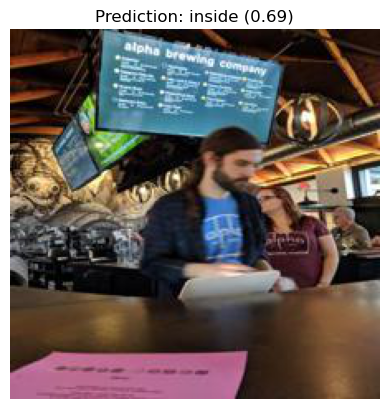

In [69]:
# Load the saved model
best_model = load_model(r"D:\Downloads\best_tuned_model.h5")

dataset_path = r"D:\Downloads\model_dataset"
class_names = sorted(os.listdir(dataset_path))

# Function to load and preprocess a random image for 48x48x3 model
def load_random_image_from_dataset(dataset_path, target_size=(48, 48)):
    class_folders = [os.path.join(dataset_path, folder) for folder in os.listdir(dataset_path)]
    random_class_folder = random.choice(class_folders)
    image_files = [f for f in os.listdir(random_class_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random_image_file = random.choice(image_files)
    img_path = os.path.join(random_class_folder, random_image_file)
    
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalize and shape to (1, 48, 48, 3)

    return img_array, img_path

# Load and predict
img_array, img_path = load_random_image_from_dataset(dataset_path)

# Predict
prediction = best_model.predict(img_array)
predicted_class_index = np.argmax(prediction)
predicted_class = class_names[predicted_class_index]

# Display result
plt.imshow(image.load_img(img_path))
plt.title(f"Prediction: {predicted_class} ({prediction[0][predicted_class_index]:.2f})")
plt.axis('off')
plt.show()

## Model Interpretability 

Lime

True label: drink


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

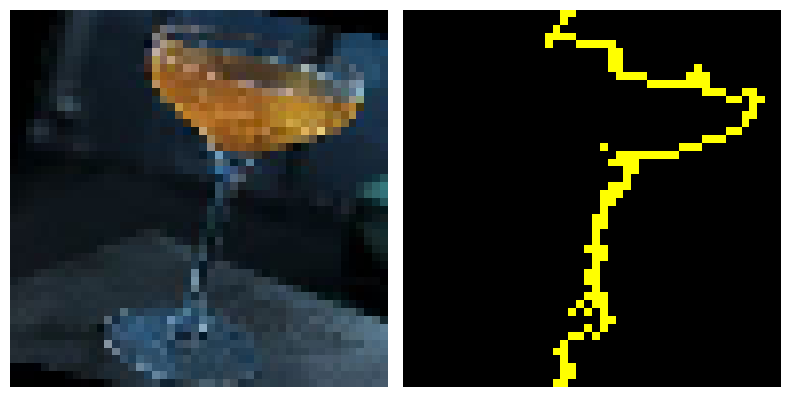

In [82]:
# Setup
img_height, img_width = 48, 48
batch_size = 32
class_names = list(train_data.class_indices.keys())

# LIME explainer
explainer = lime_image.LimeImageExplainer()

# Match preprocessing to ImageDataGenerator: resize + normalize
def preprocess_image(img):
    img = tf.image.resize(img, (img_height, img_width))  
    img = img / 255.0  # Normalize like rescale=1./255
    return img.numpy()

# Prediction wrapper for LIME
def predict_fn(images):
    images = np.array([preprocess_image(img) for img in images])
    return best_model.predict(images)

# Get validation image and label
val_data.reset()
img_batch, label_batch = next(val_data)
i = 20  # Pick the image
img = img_batch[i]
true_label_index = np.argmax(label_batch[i])
true_label = class_names[true_label_index]
print(f"True label: {true_label}")

# Run LIME explanation
explanation = explainer.explain_instance(
    image=img.astype(np.double),
    classifier_fn=predict_fn,
    top_labels=5,
    hide_color=0,
    num_samples=1000
)

# Get explanation mask
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],  # Top predicted label
    positive_only=True,
    num_features=5,
    hide_rest=False
)

# Display result
plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.imshow((img * 255).astype(np.uint8))  # Show in original scale
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.axis('off')

plt.tight_layout()
plt.show()

Shap

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Predicted class index: 4, class name: outside
SHAP value shape: (1, 48, 48, 3, 5)


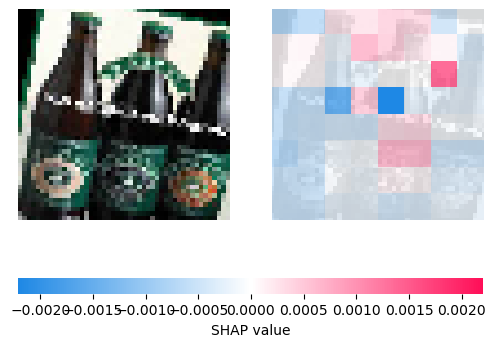

In [97]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# STEP 1: Get images
val_data.reset()
X_val_sample, _ = next(val_data)
background = X_val_sample[:20]
test_images = X_val_sample[3:4]

# STEP 2: Create the masker
masker = shap.maskers.Image("inpaint_telea", X_val_sample[0].shape)

# STEP 3: Create the explainer for your Keras model
explainer = shap.Explainer(best_model, masker, output_names=class_names)

# STEP 4: Compute SHAP values for ALL 5 classes
# THIS is where we force SHAP to explain all classes, not just top 3
shap_values = explainer(test_images, outputs=shap.Explanation.argsort.flip[:5])

# STEP 5: Get predicted class
pred_probs = best_model.predict(test_images)
pred_class = np.argmax(pred_probs)
print(f"Predicted class index: {pred_class}, class name: {class_names[pred_class]}")

# STEP 6: Confirm returned shape
print("SHAP value shape:", shap_values.values.shape)  # (1, 48, 48, 5)

# STEP 7: Plot SHAP for predicted class
shap.image_plot([shap_values.values[..., pred_class]], test_images)

# LLM Prompts 

1. How can i make class balance 
2. How to increase accuracy and reduce Loss 
3. What is kernal Tuner ?
4. Showing me index error in shap and is running slow. What should i do now ?